In [1]:
import cellcharter as cc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import seaborn as sns
import scanpy as sc
import anndata as ad
import os
import json
from scipy.stats import mannwhitneyu, kruskal, ttest_ind
import statsmodels.formula.api as smf
import scikit_posthocs as sp
import warnings
warnings.filterwarnings("ignore")

/Users/lukashat/miniforge3/envs/cellcharter_scarches/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 captum (see https://github.com/pytorch/captum).


In [2]:
extension = 'svg'
save_path = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
save_path_supp = f'/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/paper/revision/plots/{extension}/'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
adata = ad.read_h5ad("/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/results/standard/adatas/cells_final.h5ad")
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/neighborhood_color_map.json', 'r') as f:
    neighborhood_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/phenotype_color_map.json', 'r') as f:
    phenotype_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease_color_map.json', 'r') as f:
    disease_color_map = json.load(f)
with open('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/figure_plots/disease3_color_map.json', 'r') as f:
    disease3_color_map = json.load(f)
neighborhood_colors = [neighborhood_color_map[cat] for cat in list(adata.obs['cellcharter_CN'].cat.categories)]
neighborhood_colors = ListedColormap(neighborhood_colors)
phenotype_colors = [phenotype_color_map[cat] for cat in list(adata.obs['Phenotype4'].cat.categories)]
phenotype_colors = ListedColormap(phenotype_colors)
disease_colors = [disease_color_map[cat] for cat in list(adata.obs['disease2'].cat.categories)]
disease_colors = ListedColormap(disease_colors)
disease3_colors = [disease3_color_map[cat] for cat in list(adata.obs['disease3'].cat.categories)]
disease3_colors = ListedColormap(disease3_colors)

In [3]:
celltype = 'PCs'
adata.obs['disease2'] = adata.obs['disease2'].astype(str)
adata = adata[adata.obs['disease2'].isin(['MM_BD', 'MM_noBD'])]
adata.obs['disease2'] = adata.obs['disease2'].astype('category')
disease_mapping = adata.obs[['disease2', 'image_ID']].drop_duplicates()
disease_mapping.set_index('image_ID', inplace=True)

In [ ]:
pd.crosstab

In [21]:
df = adata[
    (adata.obs['Phenotype4'] == celltype)].to_df()
df['distance_to_bone_corrected'] = adata.obs.loc[df.index, 'distance_to_bone_corrected']
df['image_ID'] = adata.obs.loc[df.index, 'image_ID']
#df['disease2'] = adata.obs.loc[df.index, 'disease2']
df['distance_bin'] = pd.cut(df['distance_to_bone_corrected'], 
                           bins=range(0, 1000, 50))

In [22]:
df

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,CollagenTypeI,CD3,CPT1A,CD98,HLA-DR,ST6GAL1,CD138,distance_to_bone_corrected,image_ID,distance_bin
Object 1 in TS-373_IMC77_B_001.csv,0.285836,0.294962,0.381280,0.208380,0.470309,0.000000,0.347032,0.118177,0.245371,0.422768,...,0.698834,0.785446,0.734610,0.277531,0.523756,0.136619,0.104558,26.019224,TS-373_IMC77_B_001.csv,"(0, 50]"
Object 15 in TS-373_IMC77_B_001.csv,0.584050,0.226002,0.743808,0.527641,0.396565,0.118083,0.357526,0.018114,0.512743,0.553887,...,0.044117,0.351875,0.695553,0.258422,0.396671,0.371555,0.546733,91.241438,TS-373_IMC77_B_001.csv,"(50, 100]"
Object 32 in TS-373_IMC77_B_001.csv,0.391237,0.254091,0.419591,0.333855,0.669573,0.089656,0.375071,0.034897,0.222456,0.423251,...,1.058062,0.377810,0.568603,0.245792,0.209839,0.352995,0.122934,2.000000,TS-373_IMC77_B_001.csv,"(0, 50]"
Object 60 in TS-373_IMC77_B_001.csv,0.563274,0.243710,0.785126,0.545517,0.465828,0.098735,0.654439,0.057979,0.563328,0.603363,...,0.037422,0.263463,0.769195,0.328007,0.321675,0.445502,0.397583,86.145226,TS-373_IMC77_B_001.csv,"(50, 100]"
Object 75 in TS-373_IMC77_B_001.csv,0.608792,0.340158,0.683539,0.554623,0.654572,0.102201,0.610767,0.145675,0.482252,0.577713,...,0.304837,0.607238,0.694769,0.453150,0.501196,0.458932,0.391751,21.540659,TS-373_IMC77_B_001.csv,"(0, 50]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6578 in TS-373_IMC83_B_001.csv,0.861340,0.365933,0.825304,0.556172,0.455680,0.209952,0.649228,0.116668,0.688679,0.545271,...,0.527905,0.449939,0.817067,0.613738,0.627700,0.534086,0.286428,33.241540,TS-373_IMC83_B_001.csv,"(0, 50]"
Object 6592 in TS-373_IMC83_B_001.csv,0.726540,0.307771,0.507935,0.662648,0.277004,0.182987,0.779196,0.124444,0.637949,0.575766,...,0.307076,0.492101,0.785394,0.618533,0.494449,0.628639,0.270694,148.734663,TS-373_IMC83_B_001.csv,"(100, 150]"
Object 6593 in TS-373_IMC83_B_001.csv,0.588351,0.300972,0.336872,0.676870,0.228257,0.202051,0.836995,0.137087,0.516838,0.546555,...,0.330812,0.521410,0.831077,0.642627,0.506378,0.636885,0.119877,156.339374,TS-373_IMC83_B_001.csv,"(150, 200]"
Object 6602 in TS-373_IMC83_B_001.csv,0.762172,0.399725,0.891862,0.605014,0.512899,0.223538,0.757393,0.127421,0.464083,0.601980,...,0.483204,0.403019,0.701174,0.606858,0.582224,0.496055,0.356622,69.462220,TS-373_IMC83_B_001.csv,"(50, 100]"


In [35]:

expr = df.groupby([df['distance_bin'], df['image_ID']])[['IL32', 'HIF1A', 'GLUT1', 'ATP5A']].mean().reset_index()
expr = expr.merge(disease_mapping, on='image_ID')
expr

,distance_bin,image_ID,IL32,HIF1A,GLUT1,ATP5A,disease2
0,"(0, 50]",TS-373_IMC01_UB_001.csv,0.589564,0.546095,0.717509,0.645593,MM_noBD
1,"(0, 50]",TS-373_IMC01_UB_002.csv,0.565351,0.367902,0.755253,0.602244,MM_noBD
2,"(0, 50]",TS-373_IMC07_UB_001.csv,0.477304,0.103109,0.606735,0.746687,MM_noBD
3,"(0, 50]",TS-373_IMC07_UB_002.csv,0.403431,0.120882,0.686235,0.773570,MM_noBD
4,"(0, 50]",TS-373_IMC08_UB_001.csv,0.542578,0.122781,0.722123,0.636834,MM_BD
...,...,...,...,...,...,...,...
2465,"(900, 950]",TS-373_IMC93_B_002.csv,NaN,NaN,NaN,NaN,MM_BD
2466,"(900, 950]",TS-373_IMC95_B_001.csv,NaN,NaN,NaN,NaN,MM_BD
2467,"(900, 950]",TS-373_IMC95_B_002.csv,NaN,NaN,NaN,NaN,MM_BD
2468,"(900, 950]",TS-373_IMC96_B_001.csv,NaN,NaN,NaN,NaN,MM_BD


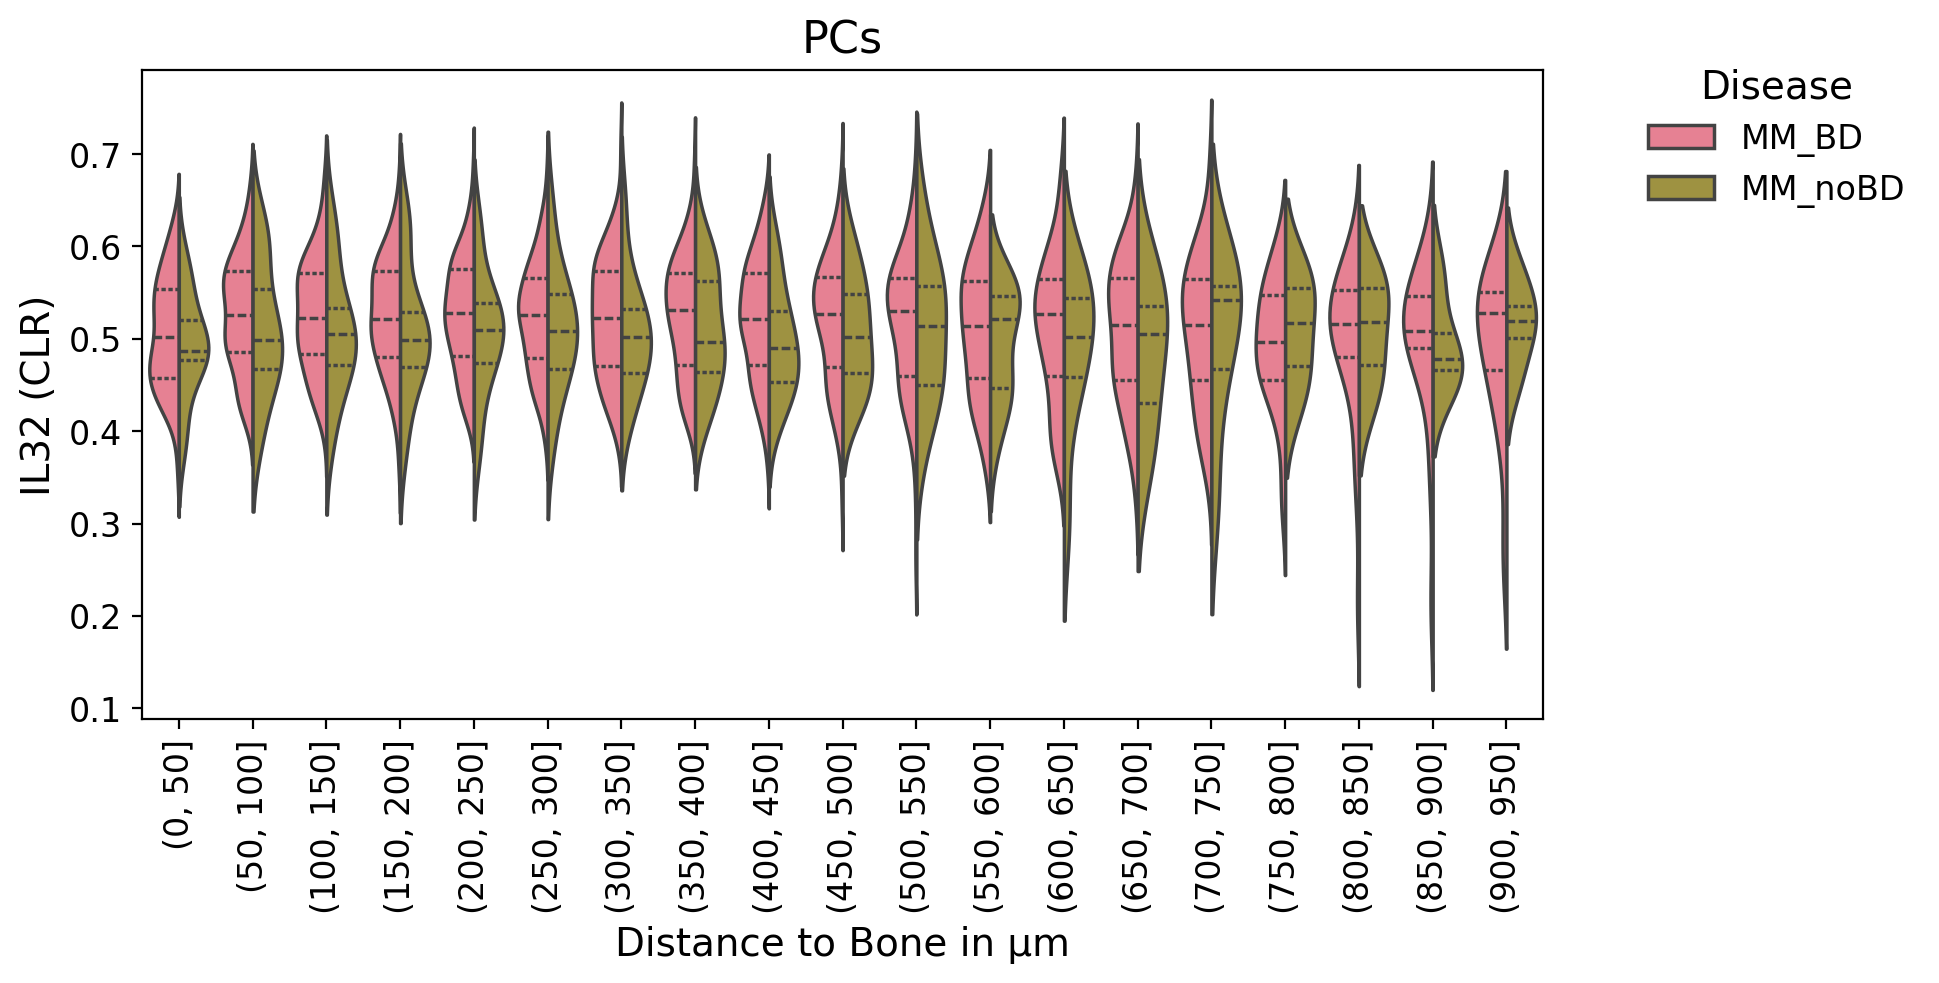

In [36]:
plt.style.use('default')
marker = 'IL32'
plt.figure(figsize=(10,5))
sns.violinplot(
    data=expr,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    inner='quartile',
    split=True,
    scale="width",
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Distance to Bone in µm", fontsize=14)
plt.ylabel(f"{marker} (CLR)", fontsize=14)
plt.legend(title='Disease', loc='upper right', bbox_to_anchor=(1.28, 1.05), framealpha=0, fontsize=12, title_fontsize=14)
plt.title(f"{celltype}", fontsize=16)
plt.tight_layout()
if celltype == 'Plasma Cells/MM cells':
    celltype_file = 'Plasma_Cells_MM_cells'
#plt.savefig(os.path.join(save_path, f"{marker}_{celltype}_distance_to_bone_violinplot.{extension}"))
plt.show()

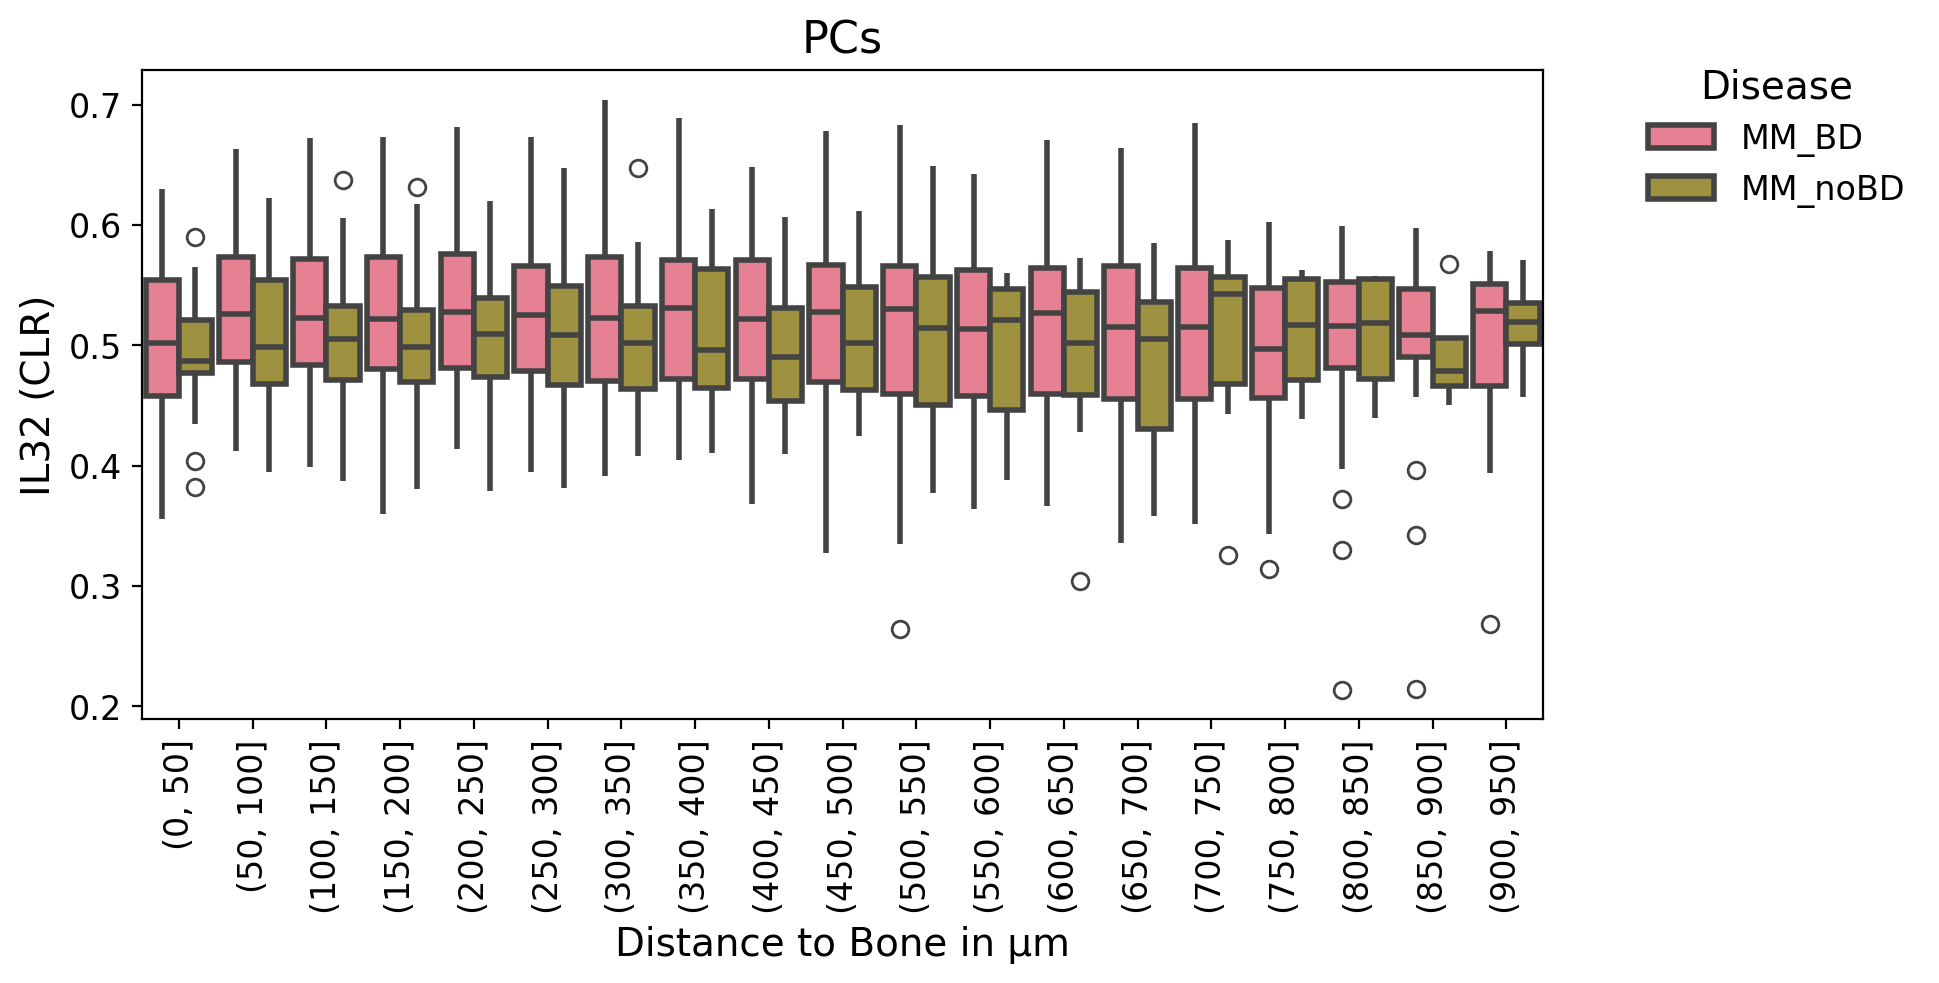

In [37]:
plt.style.use('default')
marker = 'IL32'
plt.figure(figsize=(10,5))
sns.boxplot(
    data=expr,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    showcaps=False,
    linewidth=2,
    width=0.9
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Distance to Bone in µm", fontsize=14)
plt.ylabel(f"{marker} (CLR)", fontsize=14)
plt.legend(title='Disease', loc='upper right', bbox_to_anchor=(1.28, 1.05), framealpha=0, fontsize=12, title_fontsize=14)
plt.title(f"{celltype}", fontsize=16)
plt.tight_layout()
if celltype == 'Plasma Cells/MM cells':
    celltype_file = 'Plasma_Cells_MM_cells'
#plt.savefig(os.path.join(save_path, f"{marker}_{celltype}_distance_to_bone_violinplot.{extension}"))
plt.show()

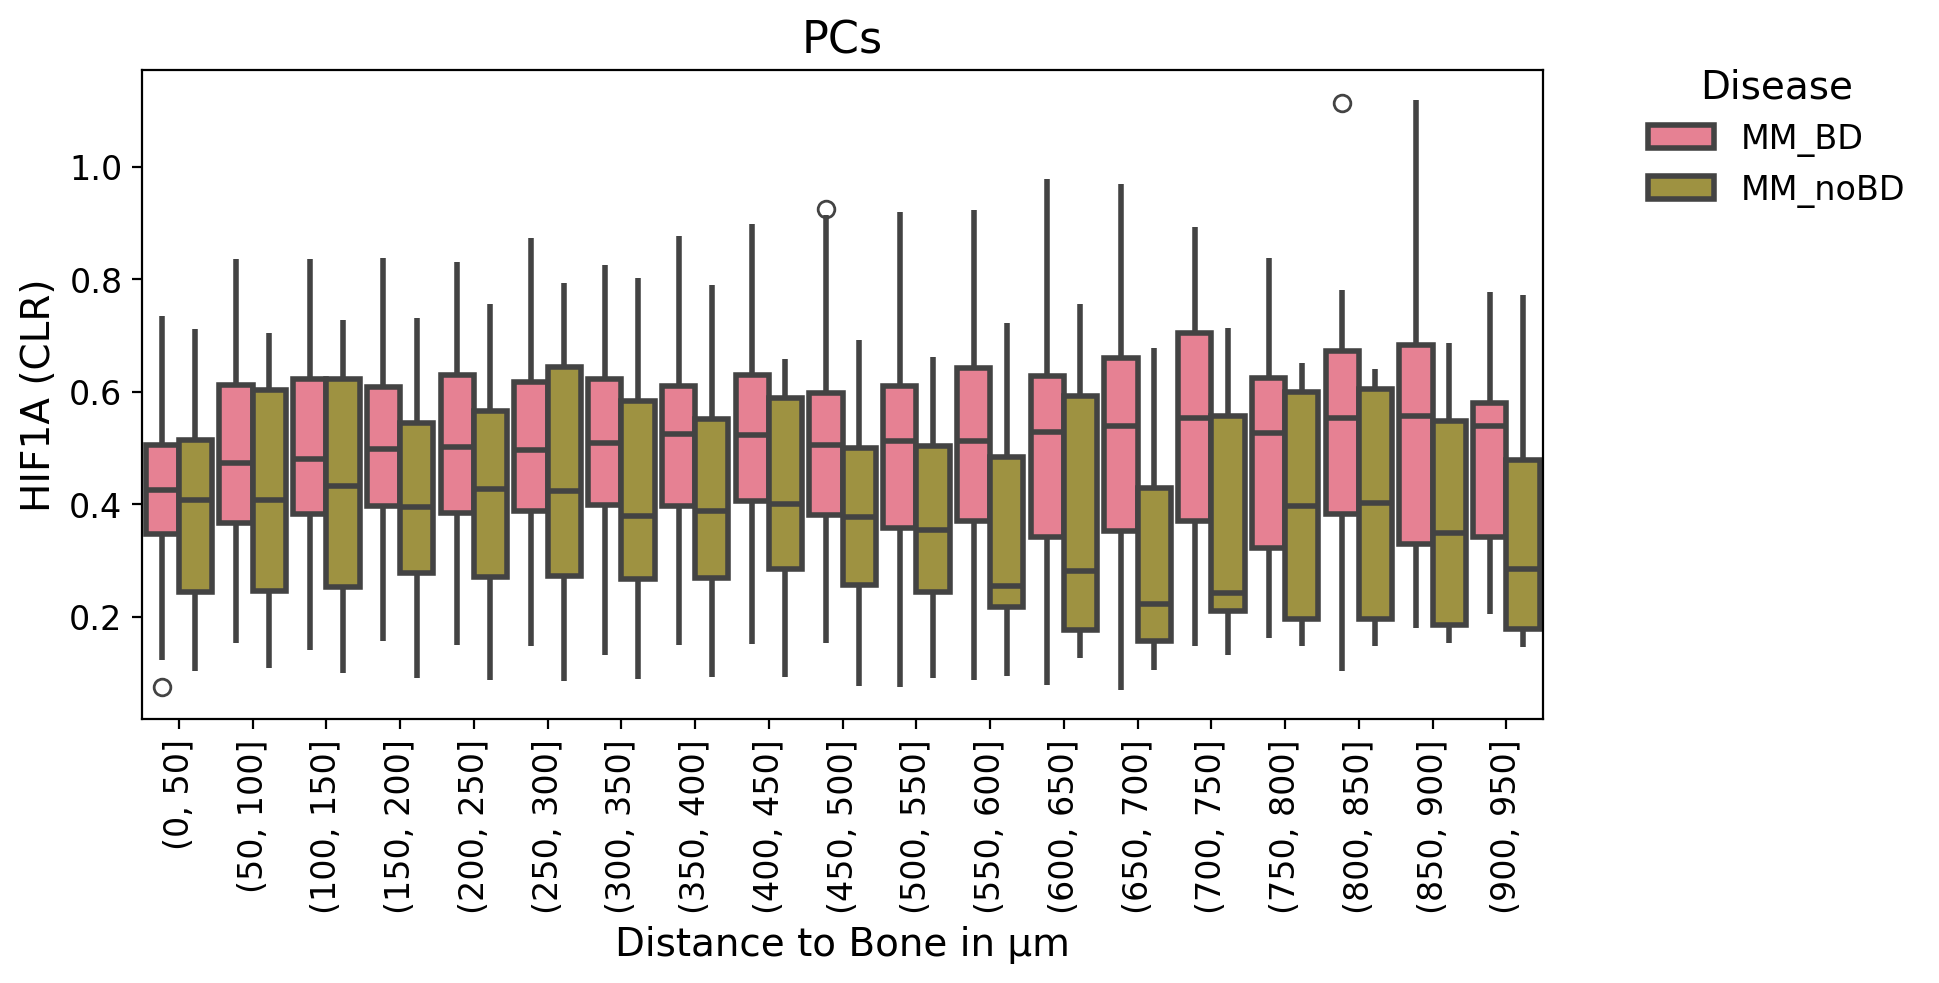

In [28]:
plt.style.use('default')
marker = 'HIF1A'
plt.figure(figsize=(10,5))
sns.boxplot(
    data=expr,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    showcaps=False,
    linewidth=2,
    width=0.9
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Distance to Bone in µm", fontsize=14)
plt.ylabel(f"{marker} (CLR)", fontsize=14)
plt.legend(title='Disease', loc='upper right', bbox_to_anchor=(1.28, 1.05), framealpha=0, fontsize=12, title_fontsize=14)
plt.title(f"{celltype}", fontsize=16)
plt.tight_layout()
if celltype == 'Plasma Cells/MM cells':
    celltype_file = 'Plasma_Cells_MM_cells'
#plt.savefig(os.path.join(save_path, f"{marker}_{celltype}_distance_to_bone_violinplot.{extension}"))
plt.show()

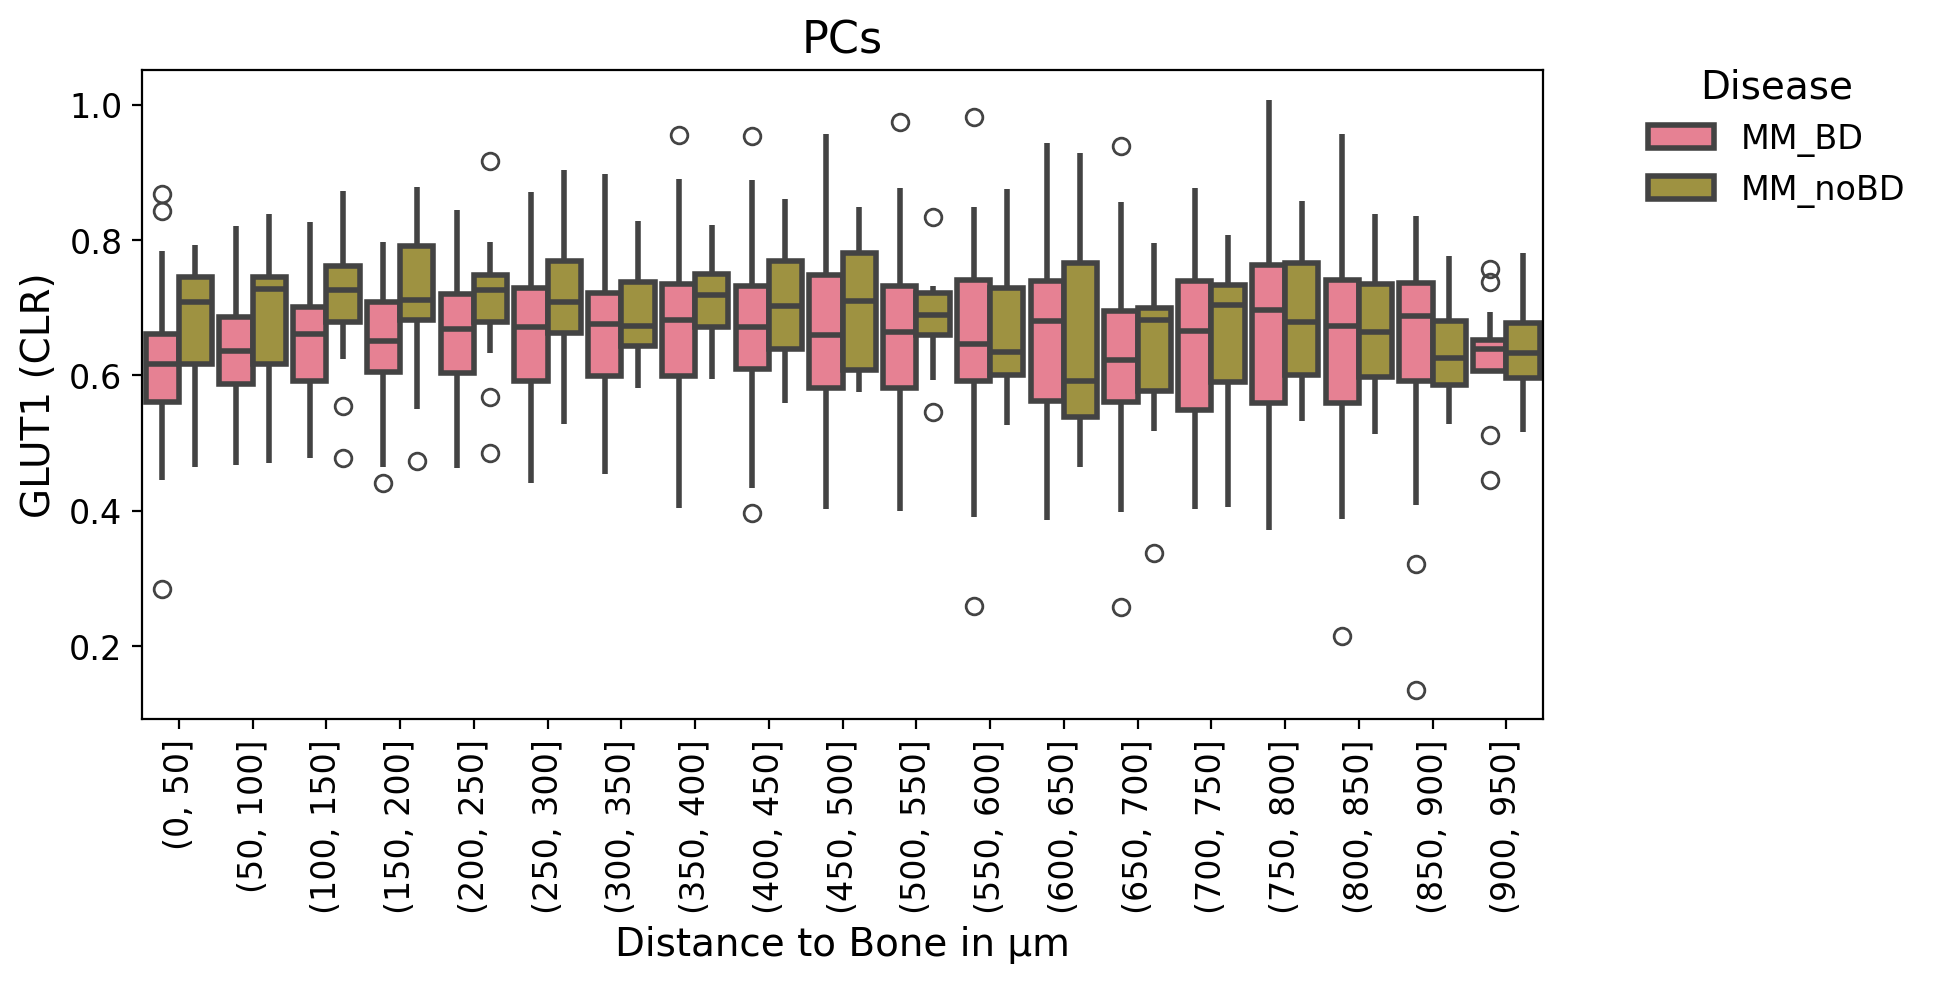

In [29]:
plt.style.use('default')
marker = 'GLUT1'
plt.figure(figsize=(10,5))
sns.boxplot(
    data=expr,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    showcaps=False,
    linewidth=2,
    width=0.9
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Distance to Bone in µm", fontsize=14)
plt.ylabel(f"{marker} (CLR)", fontsize=14)
plt.legend(title='Disease', loc='upper right', bbox_to_anchor=(1.28, 1.05), framealpha=0, fontsize=12, title_fontsize=14)
plt.title(f"{celltype}", fontsize=16)
plt.tight_layout()
if celltype == 'Plasma Cells/MM cells':
    celltype_file = 'Plasma_Cells_MM_cells'
#plt.savefig(os.path.join(save_path, f"{marker}_{celltype}_distance_to_bone_violinplot.{extension}"))
plt.show()

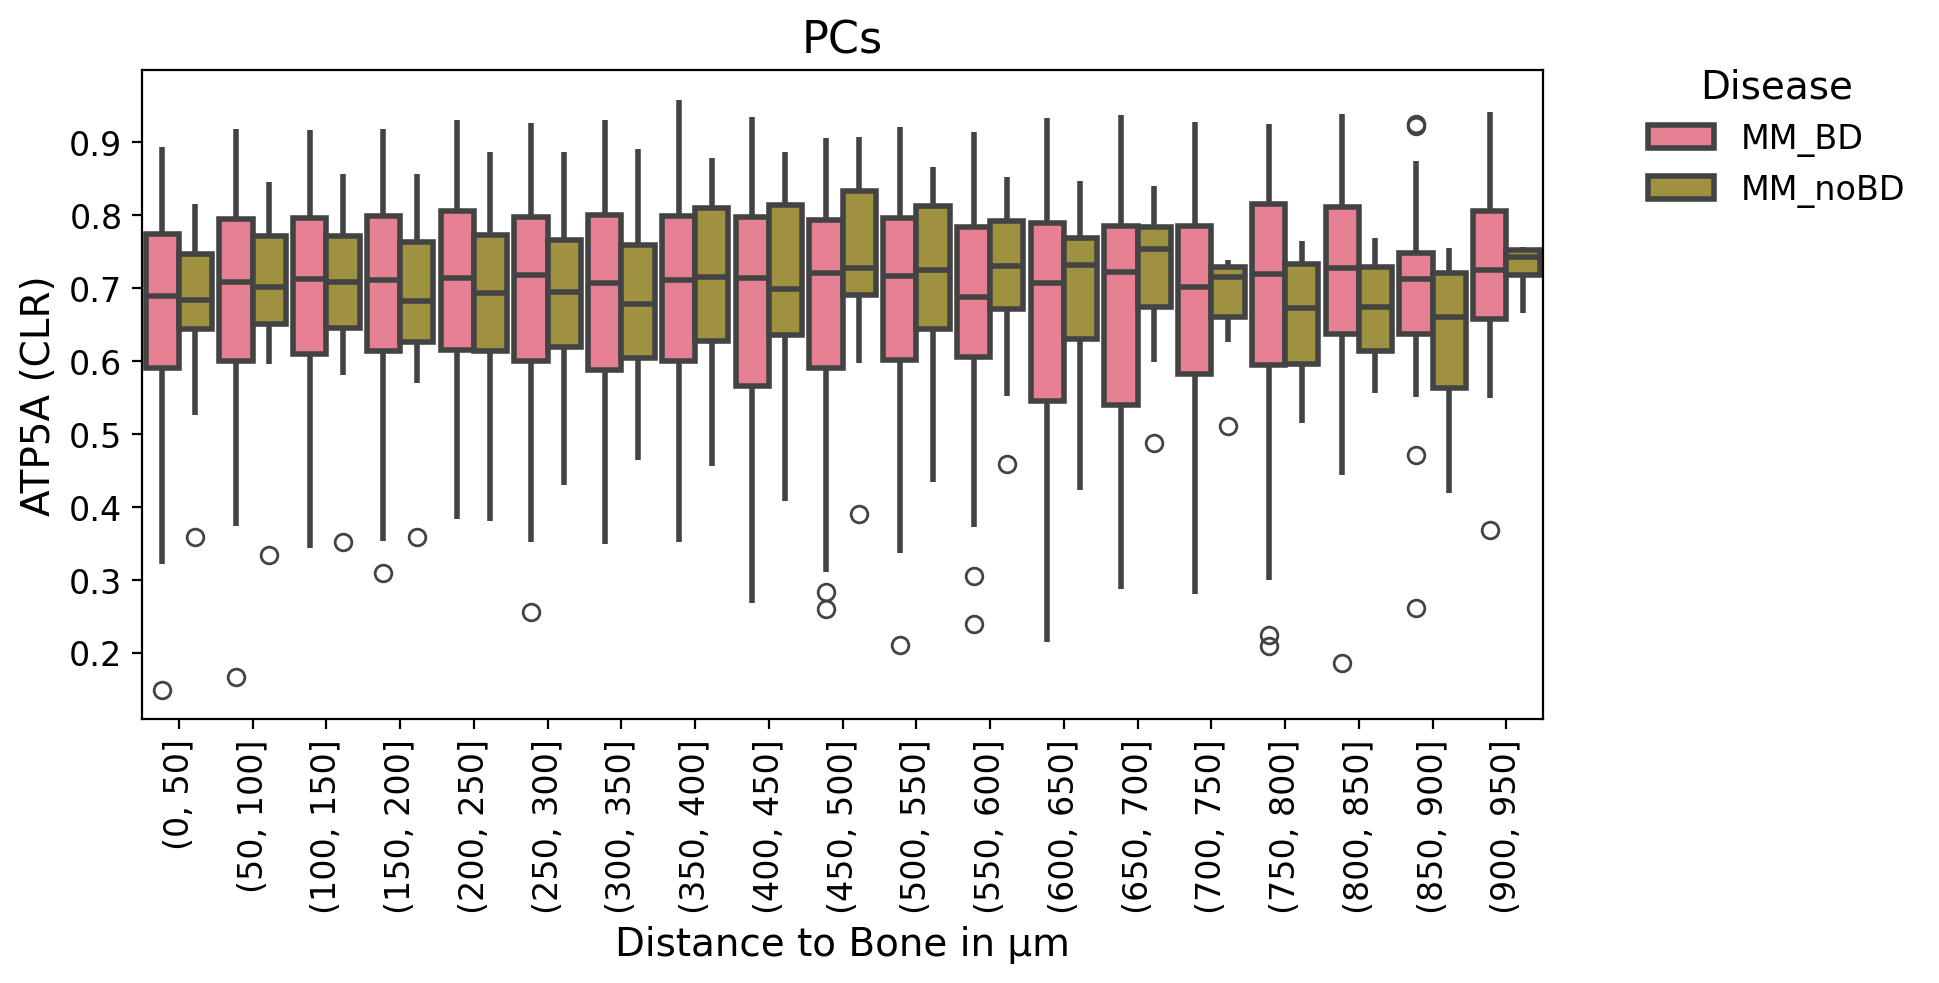

In [30]:
plt.style.use('default')
marker = 'ATP5A'
plt.figure(figsize=(10,5))
sns.boxplot(
    data=expr,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    showcaps=False,
    linewidth=2,
    width=0.9
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Distance to Bone in µm", fontsize=14)
plt.ylabel(f"{marker} (CLR)", fontsize=14)
plt.legend(title='Disease', loc='upper right', bbox_to_anchor=(1.28, 1.05), framealpha=0, fontsize=12, title_fontsize=14)
plt.title(f"{celltype}", fontsize=16)
plt.tight_layout()
if celltype == 'Plasma Cells/MM cells':
    celltype_file = 'Plasma_Cells_MM_cells'
#plt.savefig(os.path.join(save_path, f"{marker}_{celltype}_distance_to_bone_violinplot.{extension}"))
plt.show()

# dont average, use LMEM!

In [136]:
celltype = 'PCs'
adata.obs['disease2'] = adata.obs['disease2'].astype(str)
adata = adata[adata.obs['disease2'].isin(['MM_BD', 'MM_noBD'])]
adata.obs['disease2'] = adata.obs['disease2'].astype('category')
disease_mapping = adata.obs[['disease2', 'image_ID']].drop_duplicates()
disease_mapping.set_index('image_ID', inplace=True)

In [137]:
df = adata[
    (adata.obs['Phenotype4'] == celltype)].to_df()
df['distance_to_bone_corrected'] = adata.obs.loc[df.index, 'distance_to_bone_corrected']
df['disease2'] = adata.obs.loc[df.index, 'disease2']
df['image_ID'] = adata.obs.loc[df.index, 'image_ID']
df['patient_ID'] = adata.obs.loc[df.index, 'patient_ID']
df['distance_bin'] = pd.cut(df['distance_to_bone_corrected'], 
                           bins=range(0, 1001, 100))

In [138]:
print(df)

                                           CD38  Perilipin  Vimentin  \
Object 1 in TS-373_IMC77_B_001.csv     0.285836   0.294962  0.381280   
Object 15 in TS-373_IMC77_B_001.csv    0.584050   0.226002  0.743808   
Object 32 in TS-373_IMC77_B_001.csv    0.391237   0.254091  0.419591   
Object 60 in TS-373_IMC77_B_001.csv    0.563274   0.243710  0.785126   
Object 75 in TS-373_IMC77_B_001.csv    0.608792   0.340158  0.683539   
...                                         ...        ...       ...   
Object 6578 in TS-373_IMC83_B_001.csv  0.861340   0.365933  0.825304   
Object 6592 in TS-373_IMC83_B_001.csv  0.726540   0.307771  0.507935   
Object 6593 in TS-373_IMC83_B_001.csv  0.588351   0.300972  0.336872   
Object 6602 in TS-373_IMC83_B_001.csv  0.762172   0.399725  0.891862   
Object 6616 in TS-373_IMC83_B_001.csv  0.875241   0.392897  0.715341   

                                        B4GALT1       MPO  CathepsinK  \
Object 1 in TS-373_IMC77_B_001.csv     0.208380  0.470309    0

In [139]:
df.iloc[:, :33]

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,GLUT1,GranzymeB,Ki67,CollagenTypeI,CD3,CPT1A,CD98,HLA-DR,ST6GAL1,CD138
Object 1 in TS-373_IMC77_B_001.csv,0.285836,0.294962,0.381280,0.208380,0.470309,0.000000,0.347032,0.118177,0.245371,0.422768,...,0.829930,0.303835,0.133152,0.698834,0.785446,0.734610,0.277531,0.523756,0.136619,0.104558
Object 15 in TS-373_IMC77_B_001.csv,0.584050,0.226002,0.743808,0.527641,0.396565,0.118083,0.357526,0.018114,0.512743,0.553887,...,0.746775,0.359250,0.499312,0.044117,0.351875,0.695553,0.258422,0.396671,0.371555,0.546733
Object 32 in TS-373_IMC77_B_001.csv,0.391237,0.254091,0.419591,0.333855,0.669573,0.089656,0.375071,0.034897,0.222456,0.423251,...,0.749181,0.602904,0.834905,1.058062,0.377810,0.568603,0.245792,0.209839,0.352995,0.122934
Object 60 in TS-373_IMC77_B_001.csv,0.563274,0.243710,0.785126,0.545517,0.465828,0.098735,0.654439,0.057979,0.563328,0.603363,...,0.658811,0.360478,0.759769,0.037422,0.263463,0.769195,0.328007,0.321675,0.445502,0.397583
Object 75 in TS-373_IMC77_B_001.csv,0.608792,0.340158,0.683539,0.554623,0.654572,0.102201,0.610767,0.145675,0.482252,0.577713,...,0.857475,0.607524,0.398069,0.304837,0.607238,0.694769,0.453150,0.501196,0.458932,0.391751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 6578 in TS-373_IMC83_B_001.csv,0.861340,0.365933,0.825304,0.556172,0.455680,0.209952,0.649228,0.116668,0.688679,0.545271,...,0.252153,0.247453,0.149396,0.527905,0.449939,0.817067,0.613738,0.627700,0.534086,0.286428
Object 6592 in TS-373_IMC83_B_001.csv,0.726540,0.307771,0.507935,0.662648,0.277004,0.182987,0.779196,0.124444,0.637949,0.575766,...,0.628921,0.200430,0.304804,0.307076,0.492101,0.785394,0.618533,0.494449,0.628639,0.270694
Object 6593 in TS-373_IMC83_B_001.csv,0.588351,0.300972,0.336872,0.676870,0.228257,0.202051,0.836995,0.137087,0.516838,0.546555,...,0.682041,0.192316,0.337460,0.330812,0.521410,0.831077,0.642627,0.506378,0.636885,0.119877
Object 6602 in TS-373_IMC83_B_001.csv,0.762172,0.399725,0.891862,0.605014,0.512899,0.223538,0.757393,0.127421,0.464083,0.601980,...,0.416126,0.266290,0.508901,0.483204,0.403019,0.701174,0.606858,0.582224,0.496055,0.356622


In [140]:
ec_area_norm = pd.read_csv('/Users/lukashat/Documents/PhD_Schapiro/Projects/Myeloma_Standal/github/myeloma_imc/src/Paper/Revision/EC_area_to_bone_area.csv')
ec_area_norm.rename(columns={'Unnamed: 0': 'image_ID'}, inplace=True)
ec_area_norm.set_index('image_ID', inplace=True)
ec_area_norm

,Endothelial,disease2_x,bone_area,disease2_y,EC_to_bone_area
image_ID,,,,,
TS-373_IMC01_UB_001.csv,1532,MM_noBD,194110.50,MM_noBD,0.007892
TS-373_IMC01_UB_002.csv,853,MM_noBD,125435.75,MM_noBD,0.006800
TS-373_IMC02_MGUS_001.csv,30,MGUS,8558.50,MGUS,0.003505
TS-373_IMC02_MGUS_002.csv,2378,MGUS,321878.75,MGUS,0.007388
TS-373_IMC03_MGUS_001.csv,273,MGUS,147471.75,MGUS,0.001851
...,...,...,...,...,...
TS-373_IMC90.1_B_002.csv,63,MM_BD,172386.50,MM_BD,0.000365
TS-373_IMC93_B_001.csv,413,MM_BD,125131.25,MM_BD,0.003301
TS-373_IMC93_B_002.csv,164,MM_BD,83334.00,MM_BD,0.001968


In [141]:
print(ec_area_norm)

                           Endothelial disease2_x  bone_area disease2_y  \
image_ID                                                                  
TS-373_IMC01_UB_001.csv           1532    MM_noBD  194110.50    MM_noBD   
TS-373_IMC01_UB_002.csv            853    MM_noBD  125435.75    MM_noBD   
TS-373_IMC02_MGUS_001.csv           30       MGUS    8558.50       MGUS   
TS-373_IMC02_MGUS_002.csv         2378       MGUS  321878.75       MGUS   
TS-373_IMC03_MGUS_001.csv          273       MGUS  147471.75       MGUS   
...                                ...        ...        ...        ...   
TS-373_IMC90.1_B_002.csv            63      MM_BD  172386.50      MM_BD   
TS-373_IMC93_B_001.csv             413      MM_BD  125131.25      MM_BD   
TS-373_IMC93_B_002.csv             164      MM_BD   83334.00      MM_BD   
TS-373_IMC95_B_001.csv             503      MM_BD  287254.00      MM_BD   
TS-373_IMC96_B_001.csv            1500      MM_BD   24209.25      MM_BD   

                        

In [142]:
# df['EC_to_bone_area'] = df['image_ID'].map(ec_area_norm['EC_to_bone_area'])
# df.dropna(subset=['EC_to_bone_area'], inplace=True)
# df.iloc[:,:33] = df.iloc[:,:33].div(df['EC_to_bone_area'], axis=0)

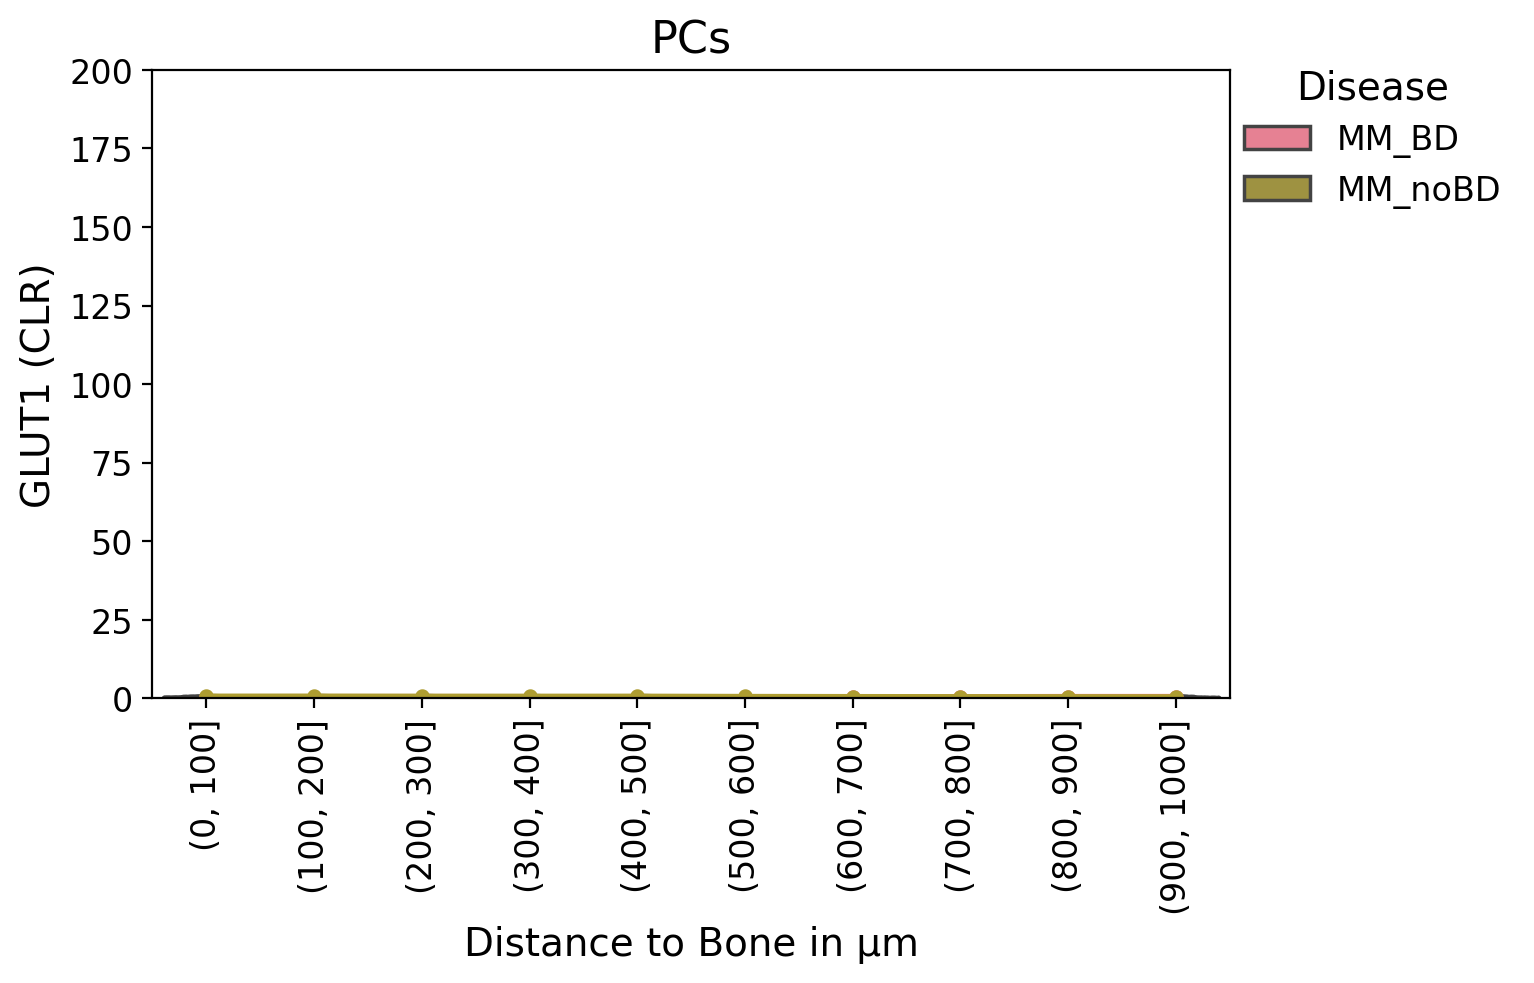

In [143]:
plt.style.use('default')
marker = 'GLUT1'
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    inner='quartile',
    split=True,
    scale="width",
)
sns.pointplot(
    data=df,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    estimator=np.median,  
    errorbar=None,   
    markers='o',        
    linestyles='-',   
    dodge=False,        
    scale=0.7,         
    legend=False,         
    zorder=2                
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Distance to Bone in µm", fontsize=14)
plt.ylabel(f"{marker} (CLR)", fontsize=14)
plt.legend(title='Disease', loc='upper right', bbox_to_anchor=(1.28, 1.05), framealpha=0, fontsize=12, title_fontsize=14)
plt.title(f"{celltype}", fontsize=16)
plt.ylim(0,200)
plt.tight_layout()
if celltype == 'Plasma Cells/MM cells':
    celltype_file = 'Plasma_Cells_MM_cells'
plt.savefig(os.path.join(save_path, f"{marker}_{celltype}_distance_to_bone_violinplot.{extension}"))
plt.show()

In [144]:
GLUT1_pvals = []
for distance_bin in df['distance_bin'].cat.categories:
    subset_df = df[df['distance_bin'] == distance_bin].copy()
    subset_df['disease2'] = pd.Categorical(
        subset_df['disease2'], 
        categories=['MM_noBD', 'MM_BD'], 
        ordered=True
    )
    
    model = smf.mixedlm(f"{marker} ~ disease2", subset_df, groups=subset_df["patient_ID"])
    result = model.fit()
    p_value = result.pvalues.get('disease2[T.MM_BD]', np.nan)
    GLUT1_pvals.append((distance_bin, p_value))

In [145]:
subset_df

,CD38,Perilipin,Vimentin,B4GALT1,MPO,CathepsinK,ATP5A,RUNX2,HIF1A,CD11b,...,CPT1A,CD98,HLA-DR,ST6GAL1,CD138,distance_to_bone_corrected,disease2,image_ID,patient_ID,distance_bin
Object 63 in TS-373_IMC86_B_002.csv,0.336524,0.230846,0.743384,0.581276,0.551938,0.118206,0.462349,0.124232,0.983773,0.791431,...,0.629143,0.550604,0.458588,0.582496,0.139341,907.573688,MM_BD,TS-373_IMC86_B_002.csv,IMC86,"(900, 1000]"
Object 126 in TS-373_IMC86_B_002.csv,0.383350,0.656063,0.895702,0.711913,0.666970,0.211863,0.673875,0.157515,0.621230,0.551842,...,0.647118,0.566941,0.807314,0.582725,0.168876,953.467881,MM_BD,TS-373_IMC86_B_002.csv,IMC86,"(900, 1000]"
Object 280 in TS-373_IMC86_B_002.csv,0.561873,0.491602,0.929763,0.577885,0.619919,0.243358,0.820473,0.073290,0.720028,0.687394,...,0.663547,0.584223,0.572677,0.600303,0.100832,937.114721,MM_BD,TS-373_IMC86_B_002.csv,IMC86,"(900, 1000]"
Object 414 in TS-373_IMC86_B_002.csv,0.559735,0.573652,1.014936,0.625559,0.423051,0.229936,0.742723,0.144287,0.501040,0.480189,...,0.695339,0.593181,0.686478,0.555910,0.091401,923.562667,MM_BD,TS-373_IMC86_B_002.csv,IMC86,"(900, 1000]"
Object 595 in TS-373_IMC86_B_002.csv,0.348552,0.559420,0.847617,0.540952,0.881267,0.285164,0.712742,0.152010,0.824979,0.653537,...,0.706627,0.483162,0.506399,0.565539,0.063910,925.851500,MM_BD,TS-373_IMC86_B_002.csv,IMC86,"(900, 1000]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Object 7588 in TS-373_IMC58_B_001.csv,0.471608,0.205394,0.477997,0.593411,0.602955,0.166220,0.562199,0.034716,0.390807,0.673395,...,0.668864,0.525791,0.580973,0.654323,0.203738,972.115734,MM_BD,TS-373_IMC58_B_001.csv,IMC58,"(900, 1000]"
Object 7597 in TS-373_IMC58_B_001.csv,0.407178,0.393459,0.306593,0.443716,0.714749,0.180515,0.337057,0.077842,0.750840,0.889823,...,0.632004,0.383467,0.273959,0.469700,0.144464,956.012552,MM_BD,TS-373_IMC58_B_001.csv,IMC58,"(900, 1000]"
Object 7610 in TS-373_IMC58_B_001.csv,0.657848,0.326284,0.845388,0.591495,0.403473,0.198535,0.758834,0.139509,0.414806,0.770947,...,0.813742,0.543383,0.454168,0.468766,0.586507,948.413412,MM_BD,TS-373_IMC58_B_001.csv,IMC58,"(900, 1000]"
Object 7611 in TS-373_IMC58_B_001.csv,0.518636,0.176791,0.280052,0.500629,0.570967,0.108730,0.286693,0.135880,0.280255,0.637183,...,0.610567,0.638961,0.521914,0.662497,0.118952,973.646753,MM_BD,TS-373_IMC58_B_001.csv,IMC58,"(900, 1000]"


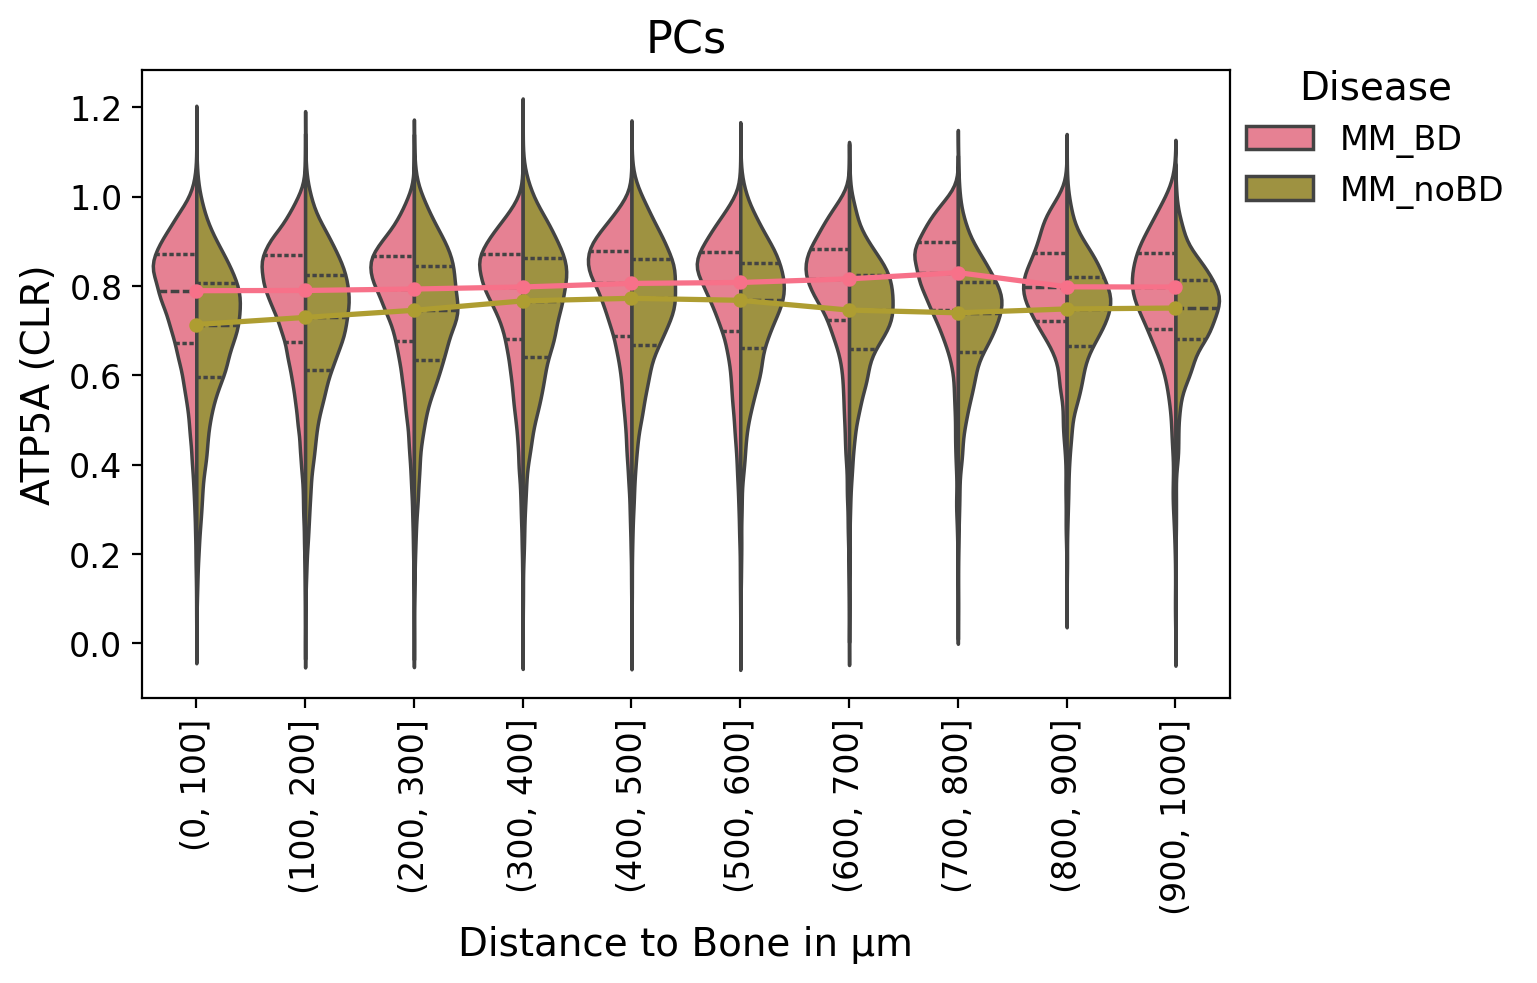

In [ ]:
plt.style.use('default')
marker = 'ATP5A'
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    inner='quartile',
    split=True,
    scale="width",
)
sns.pointplot(
    data=df,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    estimator=np.median,  
    errorbar=None,   
    markers='o',        
    linestyles='-',   
    dodge=False,        
    scale=0.7,         
    legend=False,         
    zorder=2                
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Distance to Bone in µm", fontsize=14)
plt.ylabel(f"{marker} (CLR)", fontsize=14)
plt.legend(title='Disease', loc='upper right', bbox_to_anchor=(1.28, 1.05), framealpha=0, fontsize=12, title_fontsize=14)
plt.title(f"{celltype}", fontsize=16)
plt.tight_layout()
if celltype == 'Plasma Cells/MM cells':
    celltype_file = 'Plasma_Cells_MM_cells'
plt.savefig(os.path.join(save_path, f"{marker}_{celltype}_distance_to_bone_violinplot.{extension}"))
plt.show()

In [ ]:
marker = 'ATP5A'  # Change this to CD38, Vimentin, etc. as needed
ATP5A_pvals = []
for distance_bin in df['distance_bin'].cat.categories:
    subset_df = df[df['distance_bin'] == distance_bin].copy()
    subset_df['disease2'] = pd.Categorical(
        subset_df['disease2'], 
        categories=['MM_noBD', 'MM_BD'], 
        ordered=True
    )
    
    model = smf.mixedlm(f"{marker} ~ disease2", subset_df, groups=subset_df["patient_ID"])
    result = model.fit()
    p_value = result.pvalues.get('disease2[T.MM_BD]', np.nan)
    ATP5A_pvals.append((distance_bin, p_value))

In [ ]:
ATP5A_pvals

[(Interval(0, 100, closed='right'), 0.8197364857005838),
 (Interval(100, 200, closed='right'), 0.7145406878480154),
 (Interval(200, 300, closed='right'), 0.675115494532377),
 (Interval(300, 400, closed='right'), 0.8934943624326273),
 (Interval(400, 500, closed='right'), 0.8009662046650114),
 (Interval(500, 600, closed='right'), 0.4378579772459532),
 (Interval(600, 700, closed='right'), 0.7721792096247992),
 (Interval(700, 800, closed='right'), 0.9245363474659632),
 (Interval(800, 900, closed='right'), 0.45850305335533714),
 (Interval(900, 1000, closed='right'), 0.8128150779215819)]

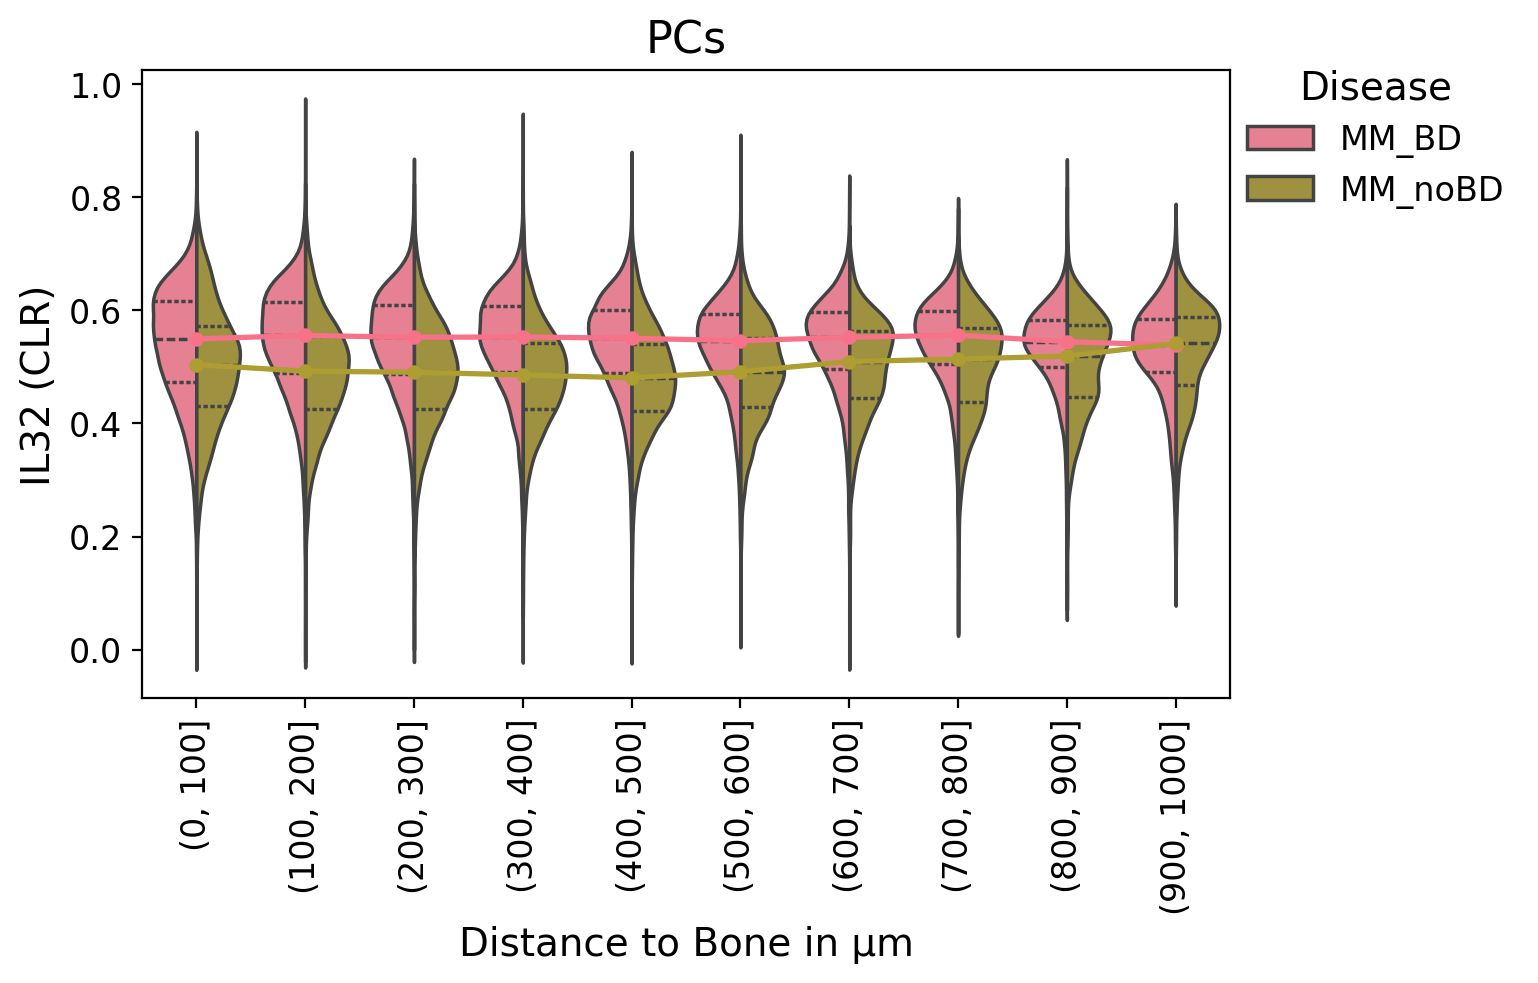

In [ ]:
plt.style.use('default')
marker = 'IL32'
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    inner='quartile',
    split=True,
    scale="width",
)
sns.pointplot(
    data=df,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    estimator=np.median,  
    errorbar=None,   
    markers='o',        
    linestyles='-',   
    dodge=False,        
    scale=0.7,         
    legend=False,         
    zorder=2                
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Distance to Bone in µm", fontsize=14)
plt.ylabel(f"{marker} (CLR)", fontsize=14)
plt.legend(title='Disease', loc='upper right', bbox_to_anchor=(1.28, 1.05), framealpha=0, fontsize=12, title_fontsize=14)
plt.title(f"{celltype}", fontsize=16)
plt.tight_layout()
if celltype == 'Plasma Cells/MM cells':
    celltype_file = 'Plasma_Cells_MM_cells'
plt.savefig(os.path.join(save_path, f"{marker}_{celltype}_distance_to_bone_violinplot.{extension}"))
plt.show()

In [ ]:
marker = 'IL32'  # Change this to CD38, Vimentin, etc. as needed
IL32_pvals = []
for distance_bin in df['distance_bin'].cat.categories:
    subset_df = df[df['distance_bin'] == distance_bin].copy()
    subset_df['disease2'] = pd.Categorical(
        subset_df['disease2'], 
        categories=['MM_noBD', 'MM_BD'], 
        ordered=True
    )
    
    model = smf.mixedlm(f"{marker} ~ disease2", subset_df, groups=subset_df["patient_ID"])
    result = model.fit()
    p_value = result.pvalues.get('disease2[T.MM_BD]', np.nan)
    IL32_pvals.append((distance_bin, p_value))

In [ ]:
IL32_pvals

[(Interval(0, 100, closed='right'), 0.3007330512280192),
 (Interval(100, 200, closed='right'), 0.2844611972897315),
 (Interval(200, 300, closed='right'), 0.46118840425131635),
 (Interval(300, 400, closed='right'), 0.5654552611738097),
 (Interval(400, 500, closed='right'), 0.29564125204552183),
 (Interval(500, 600, closed='right'), 0.641400166669658),
 (Interval(600, 700, closed='right'), 0.6980057480671549),
 (Interval(700, 800, closed='right'), 0.45229852233554135),
 (Interval(800, 900, closed='right'), 0.9692676936939153),
 (Interval(900, 1000, closed='right'), 0.5894507822998625)]

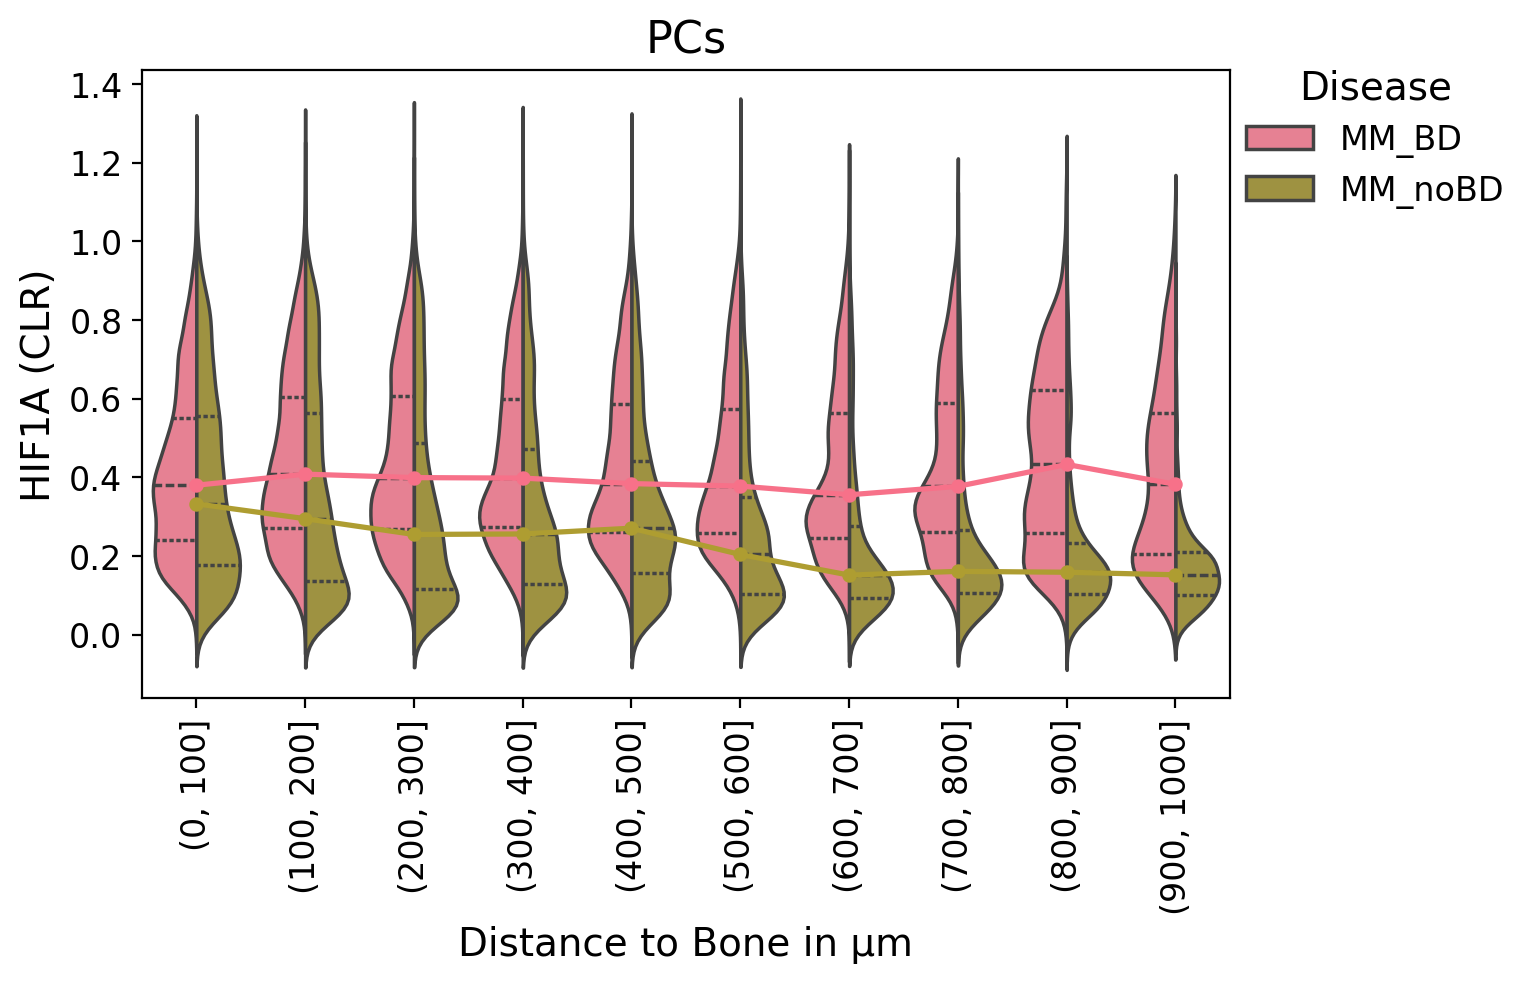

In [ ]:
plt.style.use('default')
marker = 'HIF1A'
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    inner='quartile',
    split=True,
    scale="width",
)
sns.pointplot(
    data=df,
    x="distance_bin",
    y=marker,
    hue="disease2",
    palette=disease_color_map,
    estimator=np.median,  
    errorbar=None,   
    markers='o',        
    linestyles='-',   
    dodge=False,        
    scale=0.7,         
    legend=False,         
    zorder=2                
)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Distance to Bone in µm", fontsize=14)
plt.ylabel(f"{marker} (CLR)", fontsize=14)
plt.legend(title='Disease', loc='upper right', bbox_to_anchor=(1.28, 1.05), framealpha=0, fontsize=12, title_fontsize=14)
plt.title(f"{celltype}", fontsize=16)
plt.tight_layout()
if celltype == 'Plasma Cells/MM cells':
    celltype_file = 'Plasma_Cells_MM_cells'
plt.savefig(os.path.join(save_path, f"{marker}_{celltype}_distance_to_bone_violinplot.{extension}"))
plt.show()

In [ ]:
marker = 'HIF1A'  # Change this to CD38, Vimentin, etc. as needed
HIF1A_pvals = []
for distance_bin in df['distance_bin'].cat.categories:
    subset_df = df[df['distance_bin'] == distance_bin].copy()
    subset_df['disease2'] = pd.Categorical(
        subset_df['disease2'], 
        categories=['MM_noBD', 'MM_BD'], 
        ordered=True
    )
    
    model = smf.mixedlm(f"{marker} ~ disease2", subset_df, groups=subset_df["patient_ID"])
    result = model.fit()
    p_value = result.pvalues.get('disease2[T.MM_BD]', np.nan)
    HIF1A_pvals.append((distance_bin, p_value))

In [ ]:
HIF1A_pvals

[(Interval(0, 100, closed='right'), 0.5043850472498692),
 (Interval(100, 200, closed='right'), 0.35057120546427156),
 (Interval(200, 300, closed='right'), 0.4259388617335135),
 (Interval(300, 400, closed='right'), 0.4521123559771657),
 (Interval(400, 500, closed='right'), 0.15931688472069416),
 (Interval(500, 600, closed='right'), 0.0716178785707096),
 (Interval(600, 700, closed='right'), 0.21957833507616265),
 (Interval(700, 800, closed='right'), 0.19932708140277466),
 (Interval(800, 900, closed='right'), 0.2877270372546261),
 (Interval(900, 1000, closed='right'), 0.3443271607415713)]

In [ ]:
pval_df = pd.DataFrame({
    'Distance_Bin': [bin[0] for bin in GLUT1_pvals],
    'GLUT1_pval': [bin[1] for bin in GLUT1_pvals],
    'ATP5A_pval': [bin[1] for bin in ATP5A_pvals],
    'IL32_pval': [bin[1] for bin in IL32_pvals],
    'HIF1A_pval': [bin[1] for bin in HIF1A_pvals],
})
pval_df

,Distance_Bin,GLUT1_pval,ATP5A_pval,IL32_pval,HIF1A_pval
0,"(0, 100]",0.001458,0.819736,0.300733,0.504385
1,"(100, 200]",0.003244,0.714541,0.284461,0.350571
2,"(200, 300]",0.029651,0.675115,0.461188,0.425939
3,"(300, 400]",0.199211,0.893494,0.565455,0.452112
4,"(400, 500]",0.231885,0.800966,0.295641,0.159317
5,"(500, 600]",0.576622,0.437858,0.641400,0.071618
6,"(600, 700]",0.708659,0.772179,0.698006,0.219578
7,"(700, 800]",0.866545,0.924536,0.452299,0.199327
8,"(800, 900]",0.673245,0.458503,0.969268,0.287727
9,"(900, 1000]",0.679857,0.812815,0.589451,0.344327
